In [24]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [25]:
df = pd.read_csv(r"C:\Users\user\Downloads\Mall_Customers.csv")

print(df.head())
print(df.shape)
print(df.columns)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [26]:
x=df[['Annual Income (k$)','Spending Score (1-100)']]
print(x.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [27]:
wcss=[]

In [28]:
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

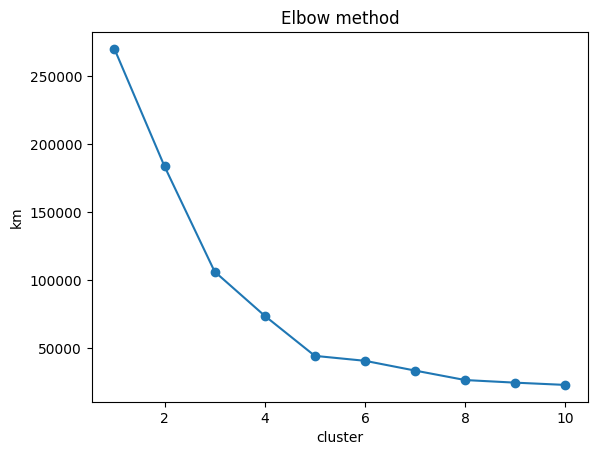

In [29]:
plt.plot(range(1,11),km,marker='o')
plt.xlabel("cluster")
plt.ylabel("km")
plt.title("Elbow method")
plt.show()

In [30]:
kmeans=KMeans(n_clusters=5,random_state=42)
df['clusters']=kmeans.fit_predict(x)

In [31]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   clusters  
0         4  
1         2  
2         4  
3         2  
4         4  


In [32]:
print(df['clusters'].value_counts())

clusters
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [33]:
print(
    df.groupby('clusters')[
        ['Annual Income (k$)',
         'Spending Score (1-100)']
    ].mean()
)

          Annual Income (k$)  Spending Score (1-100)
clusters                                            
0                  55.296296               49.518519
1                  86.538462               82.128205
2                  25.727273               79.363636
3                  88.200000               17.114286
4                  26.304348               20.913043


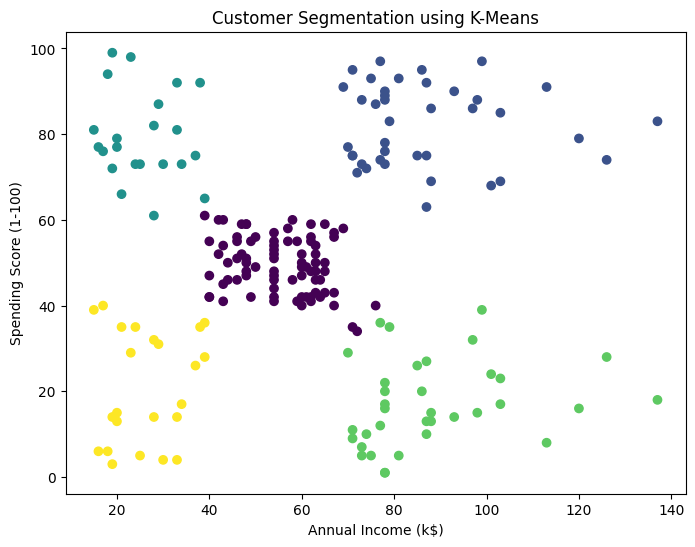

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['clusters']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()